In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data.csv")
df.head()

,name,age,nationality,height_cm,weight_kgs,body_type,positions,acceleration,sprint_speed,agility,...,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),potential_level,growth_index,strength_index,attacking_score,midfield_score,defensive_score,recommended_role
0,I. Łasicki,23,Poland,182.88,69.9,Lean,CB,52,48,57,...,1,2,2,Low,7,44.6,38.25,45.5,63.25,Defender
1,Nuno Coelho,31,Portugal,182.88,76.2,Lean,"CDM,CB",66,50,64,...,1,3,2,Medium,0,57.4,48.75,65.5,71.75,Defender
2,K. Kotsaris,22,Greece,185.42,74.8,Normal,GK,52,45,69,...,1,3,1,Medium,10,27.4,23.75,32.0,26.75,Midfielder
3,B. Parker,32,South Africa,170.18,64.9,Normal,"CF,ST,LM,CAM",74,72,77,...,1,4,3,Medium,0,71.2,71.00,68.0,28.25,Attacker
4,N. Dicko,26,Mali,172.72,73.9,Stocky,ST,89,86,79,...,1,3,3,Medium,3,65.0,66.50,61.5,43.25,Attacker


In [3]:
df.shape

(4000, 50)

In [4]:
df.columns

Index(['name', 'age', 'nationality', 'height_cm', 'weight_kgs', 'body_type',
       'positions', 'acceleration', 'sprint_speed', 'agility', 'dribbling',
       'ball_control', 'short_passing', 'long_passing', 'vision', 'finishing',
       'positioning', 'interceptions', 'standing_tackle', 'sliding_tackle',
       'strength', 'stamina', 'crossing', 'heading_accuracy', 'volleys',
       'curve', 'freekick_accuracy', 'shot_power', 'jumping', 'long_shots',
       'aggression', 'marking', 'reactions', 'balance', 'composure',
       'penalties', 'overall_rating', 'potential', 'value_euro', 'wage_euro',
       'international_reputation(1-5)', 'weak_foot(1-5)', 'skill_moves(1-5)',
       'potential_level', 'growth_index', 'strength_index', 'attacking_score',
       'midfield_score', 'defensive_score', 'recommended_role'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           4000 non-null   object 
 1   age                            4000 non-null   int64  
 2   nationality                    4000 non-null   object 
 3   height_cm                      4000 non-null   float64
 4   weight_kgs                     4000 non-null   float64
 5   body_type                      4000 non-null   object 
 6   positions                      4000 non-null   object 
 7   acceleration                   4000 non-null   int64  
 8   sprint_speed                   4000 non-null   int64  
 9   agility                        4000 non-null   int64  
 10  dribbling                      4000 non-null   int64  
 11  ball_control                   4000 non-null   int64  
 12  short_passing                  4000 non-null   i

In [6]:
y = df["potential"]

y.head()

0    67
1    72
2    77
3    70
4    71
Name: potential, dtype: int64

In [7]:
feature_cols = [
    "age", "overall_rating",
    "stamina", "strength", "balance",
    "acceleration", "sprint_speed",
    "finishing", "shot_power", "long_shots",
    "short_passing", "long_passing", "vision",
    "dribbling", "ball_control", "agility",
    "standing_tackle", "sliding_tackle", "interceptions"
]

X = df[feature_cols].copy()

X.head()

,age,overall_rating,stamina,strength,balance,acceleration,sprint_speed,finishing,shot_power,long_shots,short_passing,long_passing,vision,dribbling,ball_control,agility,standing_tackle,sliding_tackle,interceptions
0,23,60,76,65,59,52,48,32,31,34,32,32,42,41,47,57,62,64,62
1,31,72,71,68,67,66,50,33,58,52,71,65,55,57,65,64,73,68,78
2,22,67,38,66,54,52,45,18,46,13,25,22,43,13,19,69,16,14,11
3,32,70,74,39,82,74,72,70,70,69,70,61,67,75,71,77,19,24,31
4,26,68,68,80,76,89,86,66,70,54,64,54,60,67,70,79,38,36,19


Feature Engineering

In [8]:
X["growth_gap"] = df["potential"] - df["overall_rating"]
X["age_penalty"] = (df["age"] - 27).clip(lower=0)

In [9]:
X = X.fillna(X.median())

In [10]:
X.isnull().sum()

age                0
overall_rating     0
stamina            0
strength           0
balance            0
acceleration       0
sprint_speed       0
finishing          0
shot_power         0
long_shots         0
short_passing      0
long_passing       0
vision             0
dribbling          0
ball_control       0
agility            0
standing_tackle    0
sliding_tackle     0
interceptions      0
growth_gap         0
age_penalty        0
dtype: int64

In [11]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (4000, 21)
Target shape: (4000,)


In [12]:
X.describe()

,age,overall_rating,stamina,strength,balance,acceleration,sprint_speed,finishing,shot_power,long_shots,...,long_passing,vision,dribbling,ball_control,agility,standing_tackle,sliding_tackle,interceptions,growth_gap,age_penalty
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,25.594750,66.300250,63.339500,65.550750,63.563750,64.414250,64.698750,44.806750,54.970500,46.473500,...,52.59225,53.197500,54.892750,57.962750,63.016000,48.179000,46.164750,47.259000,5.178750,1.366000
std,4.722298,6.936146,15.839333,12.539447,14.051203,15.025032,14.551424,19.586815,17.503335,19.524398,...,15.55704,14.184051,19.034372,16.932485,14.755446,21.835617,21.395935,20.637645,5.571001,2.414436
min,17.000000,47.000000,14.000000,27.000000,16.000000,12.000000,13.000000,4.000000,8.000000,5.000000,...,10.00000,10.000000,5.000000,9.000000,14.000000,7.000000,3.000000,3.000000,0.000000,0.000000
25%,22.000000,62.000000,56.000000,58.000000,55.000000,57.000000,57.000000,29.000000,45.000000,31.000000,...,42.00000,43.000000,48.000000,53.000000,55.000000,26.750000,24.000000,26.000000,0.000000,0.000000
50%,25.000000,66.000000,67.000000,67.000000,66.000000,67.000000,67.000000,48.000000,59.000000,50.000000,...,56.00000,55.000000,61.000000,63.000000,65.000000,56.000000,53.000000,53.000000,3.000000,0.000000
75%,29.000000,71.000000,74.000000,75.000000,74.000000,75.000000,75.000000,61.000000,68.000000,62.000000,...,64.00000,64.000000,68.000000,69.000000,73.000000,66.000000,64.000000,64.000000,9.000000,2.000000
max,41.000000,91.000000,94.000000,93.000000,96.000000,96.000000,96.000000,94.000000,94.000000,90.000000,...,93.00000,90.000000,91.000000,93.000000,94.000000,91.000000,89.000000,90.000000,25.000000,14.000000


MODEL TRAINING & EVALUATION

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (3200, 21)
Test set: (800, 21)


------Baseline Model — Linear Regression ---------

In [14]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluate
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", round(mae_lr, 2))
print("R² Score:", round(r2_lr, 3))

Linear Regression Results
MAE: 0.0
R² Score: 1.0


----------- Main Model — Random Forest Regressor-------------

In [15]:
# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", round(mae_rf, 2))
print("R² Score:", round(r2_rf, 3))

Random Forest Results
MAE: 0.16
R² Score: 0.995


In [16]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "R2 Score": [r2_lr, r2_rf]
})

comparison

,Model,MAE,R2 Score
0,Linear Regression,1.135092e-14,1.00000
1,Random Forest,1.606125e-01,0.99499


In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
1,overall_rating,0.667017
19,growth_gap,0.320609
0,age,0.005912
17,sliding_tackle,0.000440
2,stamina,0.000436
16,standing_tackle,0.000428
7,finishing,0.000417
18,interceptions,0.000416
3,strength,0.000405
15,agility,0.000386


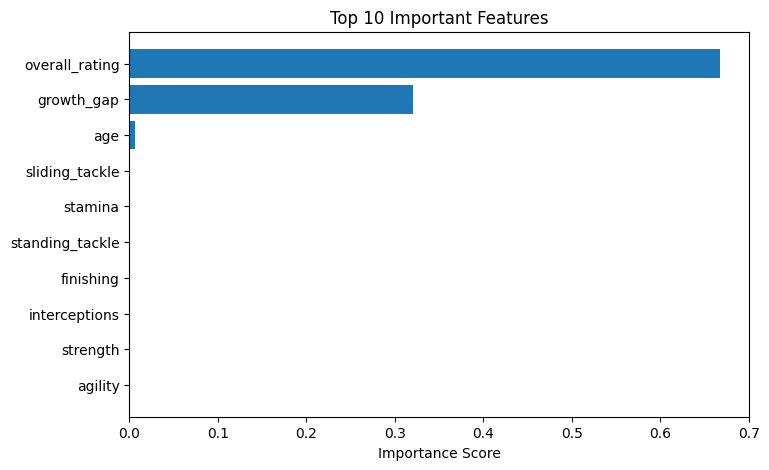

In [18]:
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

Test Prediction on a Single Player

In [19]:
sample_player = X_test.iloc[0:1]
actual = y_test.iloc[0]
predicted = rf.predict(sample_player)[0]

print("Actual Potential:", actual)
print("Predicted Potential:", round(predicted, 1))

Actual Potential: 66
Predicted Potential: 66.0


In [20]:
import joblib

In [21]:

joblib.dump(rf, "future_overall_rf_model.joblib")

['future_overall_rf_model.joblib']

In [22]:

joblib.dump(X.columns.tolist(), "model_features.joblib")

['model_features.joblib']

------Load model & features back------

In [23]:

loaded_model = joblib.load("future_overall_rf_model.joblib")
loaded_features = joblib.load("model_features.joblib")

print("Loaded model:", type(loaded_model))
print("Number of features:", len(loaded_features))

Loaded model: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Number of features: 21


Predict using loaded model

In [24]:

sample = X_test.iloc[0:1][loaded_features]
pred = loaded_model.predict(sample)[0]

print("Predicted Potential:", round(pred, 2))

Predicted Potential: 66.0
